# Feature selection

## Setup

### Imports and functions

In [1]:
import pandas as pd
import glob #For combining individual files into one dataframe
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
def plot_voyage_on_coastline(voyage_data, coastline_data, padding=0.05) -> None:
    """
    Function to plot a voyage's trajectory on a coastline map.

    Args:
        voyage_data: DataFrame containing voyage data, including latitude, longitude, and timestamps.
        coastline_data: GeoDataFrame containing coastline data in GeoPandas format.
        padding: Float padding around the trajectory for zooming.
    """
    
    # Ensure the data is sorted by timestamp
    voyage_data = voyage_data.sort_values(by="pos_timestamp", ascending=True, inplace=False)

    # Get min/max latitudes and longitudes from the voyage data to define the zoom area
    min_lon, max_lon = voyage_data.longitude.min(), voyage_data.longitude.max()
    min_lat, max_lat = voyage_data.latitude.min(), voyage_data.latitude.max()

    # Add some padding to the zoom area
    xlim = (min_lon - padding, max_lon + padding)
    ylim = (min_lat - padding, max_lat + padding)

    # Create the plot
    _, ax = plt.subplots(figsize=(10, 6))

    # Plot the coastline
    coastline_data.plot(ax=ax, color="black", linewidth=0.8, label="Coastline")

    # Plot the vessel trajectory
    ax.plot(voyage_data.longitude, voyage_data.latitude, marker="o", linestyle="-", color="b", label="Voyage Trajectory")

    # Set axis limits for zooming in
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Labels and title
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Voyage Trajectory on Coastline Map")

    # Show legend and grid
    ax.legend()
    ax.grid()

    # Show the plot
    plt.show()

In [3]:
def load_parquet(path_pattern: str, engine='fastparquet') -> pd.DataFrame:
    """
    Loads parquet file(s).
    Supports glob patterns like "*.parquet.gzip".
    
    Args:
        path_pattern: File path or glob pattern.
        engine: Parquet engine.

    Returns:
        Single DataFrame, concatenated if multiple files.
    """

    files = glob.glob(path_pattern)
    if not files:
        raise FileNotFoundError(f"No files found matching: {path_pattern}")
    
    dfs = [pd.read_parquet(f, engine=engine) for f in files]
    df = pd.concat(dfs, ignore_index=True) if len(dfs) > 1 else dfs[0]
    print(f"Loaded {len(df):,} rows from {len(dfs)} files matching \"{path_pattern}\"")
    
    return df

## Load coastline map

<Axes: >

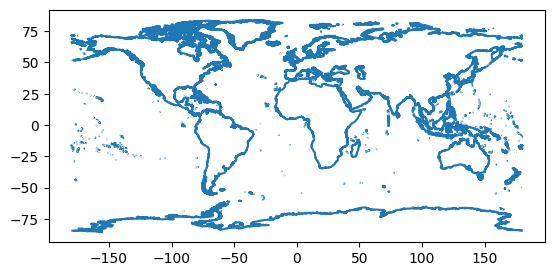

In [ ]:
# Load coastline map data from Natural Earth 
# longitude, horizontal
# latitude, vertical
import geopandas as gpd
coastline = gpd.read_file("./data/ne_10m_coastline/ne_10m_coastline.shp")
coastline.plot()

## Load AIS data and voyage META data
We're only interested in arrivals to Valencia, as it's there we aim to optimize berth allocation and scheduling, thus we can forego departures.

In [5]:
arrivals_ais_data = load_parquet("./data/mission-voyage-examples/ESVLC-arrivals-voyage-ais-data-*.parquet.gzip")
arrivals_ais_meta_data = load_parquet("./data/mission-voyage-examples/ESVLC-arrivals-voyage-metadata-*.parquet.gzip")

Loaded 3,311,442 rows from 12 files matching "./data/mission-voyage-examples/ESVLC-arrivals-voyage-ais-data-*.parquet.gzip"
Loaded 43,352 rows from 12 files matching "./data/mission-voyage-examples/ESVLC-arrivals-voyage-metadata-*.parquet.gzip"


### Inspect AIS data

In [6]:
arrivals_ais_data.shape

(3311442, 50)

In [7]:
arrivals_ais_data.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month'],
      dtype='object')

In [8]:
arrivals_ais_data.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,capacity_liquid_gas,capacity_passenger,capacity_liquid_oil,commercial_size_class,vessel_type_details,draught_max,draught_min,capacity_nt,vid_prefix,month
0,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:11:09,UNDEFINED,False,-0.330460,39.426970,360.000000,511,...,0,0,0,,,0.0,0.0,0,00,2024-01
1,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:29:09,UNDEFINED,False,-0.330560,39.426960,360.000000,511,...,0,0,0,,,0.0,0.0,0,00,2024-01
2,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:50:10,UNDEFINED,False,-0.330510,39.426940,360.000000,511,...,0,0,0,,,0.0,0.0,0,00,2024-01
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,0,0,0,HANDYSIZE,Bulk Carrier,10.6,4.8,10500,01,2024-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,0,0,0,HANDYSIZE,Bulk Carrier,10.6,4.8,10500,01,2024-01


### Inspect voyage META data

In [9]:
arrivals_ais_meta_data.shape

(43352, 17)

In [10]:
arrivals_ais_meta_data.columns

Index(['voyage_id', 'mmsi', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude',
       'prev_voyage_id', 'next_voyage_id', 'departed_port_call_id',
       'arrived_port_call_id', 'duration', 'arrival_country', 'arrival_date'],
      dtype='object')

In [11]:
arrivals_ais_meta_data.head()

,voyage_id,mmsi,departure_time,departure_locode,departure_latitude,departure_longitude,arrival_time,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
0,f4a7d707-95c8-4e3f-93f4-c6000e57853a,224208000,2024-01-15 22:57:24,ESVLC,39.441430,-0.317925,2024-01-15 23:58:36,ESVLC,39.442105,-0.317382,f49ebf4b-71a0-4c81-8317-59d5930c79ed,864c813c-e3d1-4627-9088-750d4bcb9f96,,,3672.0,ES,2024-01-16
1,597c19e1-449b-49a3-9044-62788862926a,225952430,2024-01-15 22:54:55,ESVLC,39.421110,-0.329000,2024-01-16 00:00:00,ESVLC,39.424800,-0.327170,b228aff6-44bb-479c-8cef-ea39fd47b4f0,f01811e2-e6ce-49e6-8877-60d7b326d46e,,,3905.0,ES,2024-01-16
2,ec23c291-f150-4314-a4b7-5834e47c7f7a,255915587,2024-01-15 22:22:37,ESVLC,39.394322,-0.275112,2024-01-16 00:33:06,ESVLC,39.434488,-0.327693,776e4362-e3f9-47ea-97d4-df89891f1204,03f0aad7-0ec9-4f83-a8d4-335b75906a29,,,7829.0,ES,2024-01-16
3,98074eeb-fe2a-4478-8e51-8c9ea2aed4f6,205345130,2024-01-15 22:53:39,ESVLC,39.430230,-0.332620,2024-01-16 00:29:40,ESVLC,39.430240,-0.332640,2737f7cd-015c-45bc-9bd4-d0f2134b917c,e20b07a6-59b9-47f0-92af-c91892a34149,,,5761.0,ES,2024-01-16
4,4c617e21-5ff2-423e-9c81-d4e3b61986dd,255806500,2024-01-15 11:17:21,ESBCN,41.310288,2.150347,2024-01-16 00:39:26,ESVLC,39.439080,-0.325422,115375ca-6147-4c60-910f-13ef7da40f06,2d6446e8-b61b-4da4-aefe-9d949aaac8ec,,,48125.0,ES,2024-01-16


#### Check if the voyage META data contains any duplicates

In [12]:
dupe_mask = arrivals_ais_meta_data["voyage_id"].duplicated(keep="first")
dupes = arrivals_ais_meta_data[dupe_mask].copy()

print(f"Duplicated rows: {len(dupes)}")

if (len(dupes)):
    dupes.head()

Duplicated rows: 0


### Merging AIS data with voyage META data
The AIS data is the dynamic, continuously transmitted AIS data samples from vessels, whereas the META data represents the static information of the voyage.
This means the META data includes e.g. the duration of the voyage, i.e. our truth values for supervised ML.
Thus we merge them into a single DataFrame.

In [13]:
ais_meta_merged = arrivals_ais_data.merge(
    arrivals_ais_meta_data,
    on="voyage_id",
    how="left",
    suffixes=("_ais", "_meta"), # column name suffix if both DataFrames contain the same column
)

#### Check how many AIS data samples have voyage META data

In [14]:
has_meta_pct = ais_meta_merged["arrival_time"].notna().mean() * 100
print(f"{has_meta_pct:.2f}% of AIS data samples have META data")

100.00% of AIS data samples have META data


In [15]:
ais_meta_merged.shape

(3311442, 66)

In [16]:
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi_ais', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'mmsi_meta', 'departure_time',
       'departure_locode', 'departure_latitude', 'departure_longitude',
       'arrival_time', 'arrival_locode', 'arrival_latitude',
  

In [17]:
ais_meta_merged.head()

,voyage_id,voyage_status,mmsi_ais,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
0,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:11:09,UNDEFINED,False,-0.330460,39.426970,360.000000,511,...,ESVLC,39.426980,-0.33052,fe242117-538c-4d82-bb4a-4195d8290a6b,041bbc52-764f-47cc-9322-b6472389860c,,,4253.0,ES,2024-01-01
1,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:29:09,UNDEFINED,False,-0.330560,39.426960,360.000000,511,...,ESVLC,39.426980,-0.33052,fe242117-538c-4d82-bb4a-4195d8290a6b,041bbc52-764f-47cc-9322-b6472389860c,,,4253.0,ES,2024-01-01
2,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:50:10,UNDEFINED,False,-0.330510,39.426940,360.000000,511,...,ESVLC,39.426980,-0.33052,fe242117-538c-4d82-bb4a-4195d8290a6b,041bbc52-764f-47cc-9322-b6472389860c,,,4253.0,ES,2024-01-01
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01


### Check if mmsi_ais and mmsi_meta are equal
If so, drop mmsi_meta column and rename mmsi_ais to mmsi

In [18]:
same_mmsi_mask = ais_meta_merged["mmsi_ais"] == ais_meta_merged["mmsi_meta"]
pct_same = same_mmsi_mask.mean() * 100
print(f"mmsi_ais and mmsi_meta match in {pct_same:.2f}% of merged rows")


mmsi_ais and mmsi_meta match in 100.00% of merged rows


In [19]:
ais_meta_merged = ais_meta_merged.drop("mmsi_meta", axis="columns")
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi_ais', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longit

In [20]:
ais_meta_merged.rename(columns={"mmsi_ais": "mmsi"}, inplace=True)

In [21]:
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude'

## Pre-processing

### Defining population

#### Filter out non-commercial vessels

In [22]:
ais_meta_merged["vessel_type_details"].unique()

array(['', 'Bulk Carrier', 'General Dry Cargo', 'Chemical Tanker',
       'Container Ship', 'Offshore', 'Tanker', 'Roll-on Roll-off',
       'Vehicle/Passenger', 'Pure Car Carrier', 'Miscellaneous',
       'Passenger Ship', 'LPG Carrier'], dtype=object)

In [23]:
ais_meta_merged["vessel_type_details"].value_counts(normalize=True).mul(100).round(2)

vessel_type_details
                     64.83
Container Ship       23.16
Roll-on Roll-off      2.51
Chemical Tanker       2.12
Tanker                1.91
General Dry Cargo     1.32
Pure Car Carrier      1.32
Bulk Carrier          1.26
Offshore              1.22
Vehicle/Passenger     0.24
Passenger Ship        0.06
Miscellaneous         0.05
LPG Carrier           0.01
Name: proportion, dtype: float64

In [24]:
VALID_VESSEL_TYPES = ["Bulk Carrier", "General Dry Cargo", "Chemical Tanker", "Container Ship", "Tanker", "LPG Carrier", "Pure Car Carrier", "Roll-on Roll-off"]

mask = ais_meta_merged["vessel_type_details"].isin(VALID_VESSEL_TYPES)
cargo_ais_meta_merged = ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
5,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:33:22,AT_ANCHOR,True,-0.257378,39.395087,242.300003,244,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
6,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:48:22,AT_ANCHOR,True,-0.257395,39.395017,250.000000,248,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
10,01f80139-2bd0-4ff0-8cdd-33c0064ba220,PENDING_DEPARTURE,577005000,2024-01-29 21:02:50,MOORED,False,-0.321315,39.445050,178.199997,111,...,ESVLC,39.445048,-0.321325,10b4dad4-687a-48c3-ad7d-0d79adea92e7,a6910090-2954-47dc-89ad-22f0139013d7,,,3611.0,ES,2024-01-31


#### Filter out voyages with invalid voyage status

In [25]:
cargo_ais_meta_merged["voyage_status"].unique()

array(['STOPPED', 'PENDING_DEPARTURE', 'UNDER_WAY', 'COMPLETED'],
      dtype=object)

In [26]:
cargo_ais_meta_merged["voyage_status"].value_counts(normalize=True).mul(100).round(2)

voyage_status
UNDER_WAY            51.19
PENDING_DEPARTURE    32.44
STOPPED              15.63
COMPLETED             0.74
Name: proportion, dtype: float64

In [27]:
VALID_VOYAGE_STATUSES = ["UNDER_WAY", "STOPPED"]

mask = cargo_ais_meta_merged["voyage_status"].isin(VALID_VOYAGE_STATUSES)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
5,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:33:22,AT_ANCHOR,True,-0.257378,39.395087,242.300003,244,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
6,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:48:22,AT_ANCHOR,True,-0.257395,39.395017,250.000000,248,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
22,029a4b25-666a-41dd-ad98-f3dd0b467c92,UNDER_WAY,620331000,2024-01-01 05:48:00,UNDER_WAY_USING_ENGINES,True,3.033163,38.986765,277.799988,274,...,ESVLC,39.444928,-0.32074,26d91f33-f8bb-4ea2-8a89-50cefa59059c,a314bc7a-6bfb-4968-9e93-fec84a4bffa6,,,664483.0,ES,2024-01-03


#### Filter out voyages with missing MMSI

In [28]:
voyages_with_valid_mmsi_pct = cargo_ais_meta_merged["mmsi"].notna().mean() * 100
print(f"Voyages with valid MMSI: {voyages_with_valid_mmsi_pct:.2f}%")

Voyages with valid MMSI: 100.00%


#### Filter out voyages with invalid navigation statuses

In [29]:
cargo_ais_meta_merged["navigation_status"].unique()

array(['AT_ANCHOR', 'UNDER_WAY_USING_ENGINES', 'MOORED',
       'NOT_UNDER_COMMAND', 'CONSTRAINED_BY_HER_DRAUGHT',
       'UNDER_WAY_SAILING', 'RESTRICTED_MANEUVERABILITY', 'UNDEFINED',
       'AGROUND', 'PUSHING_AHEAD_OR_TOWING_ALONGSIDE',
       'ENGAGED_IN_FISHING'], dtype=object)

In [30]:
cargo_ais_meta_merged["navigation_status"].value_counts(normalize=True).mul(100).round(2)

navigation_status
UNDER_WAY_USING_ENGINES              80.81
AT_ANCHOR                            16.11
MOORED                                2.41
UNDER_WAY_SAILING                     0.41
NOT_UNDER_COMMAND                     0.14
RESTRICTED_MANEUVERABILITY            0.06
CONSTRAINED_BY_HER_DRAUGHT            0.04
UNDEFINED                             0.01
AGROUND                               0.01
PUSHING_AHEAD_OR_TOWING_ALONGSIDE     0.00
ENGAGED_IN_FISHING                    0.00
Name: proportion, dtype: float64

In [31]:
VALID_NAVIGATION_STATUSES = [
       'UNDER_WAY_USING_ENGINES', 'MOORED', 'AT_ANCHOR',
       'CONSTRAINED_BY_HER_DRAUGHT', 'UNDER_WAY_SAILING',
       'RESTRICTED_MANEUVERABILITY',
       'PUSHING_AHEAD_OR_TOWING_ALONGSIDE']

mask = cargo_ais_meta_merged["navigation_status"].isin(VALID_NAVIGATION_STATUSES)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
5,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:33:22,AT_ANCHOR,True,-0.257378,39.395087,242.300003,244,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
6,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:48:22,AT_ANCHOR,True,-0.257395,39.395017,250.000000,248,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
22,029a4b25-666a-41dd-ad98-f3dd0b467c92,UNDER_WAY,620331000,2024-01-01 05:48:00,UNDER_WAY_USING_ENGINES,True,3.033163,38.986765,277.799988,274,...,ESVLC,39.444928,-0.32074,26d91f33-f8bb-4ea2-8a89-50cefa59059c,a314bc7a-6bfb-4968-9e93-fec84a4bffa6,,,664483.0,ES,2024-01-03


In [92]:
cargo_ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'ship_type',
       'position_device', 'eta', 'draught', 'meta_timestamp', 'build_year',
       'length', 'width', 'capacity_dwt', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'month', 'departure_time', 'departure_locode', 'departure_latitude',
       'departure_longitude', 'arrival_time', 'arrival_latitude',
       'arrival_longitude', 'duration', 'arrival_date', 'tta', 'tta_hours'],
      dtype='object')

In [88]:
cargo_ais_meta_merged["speed_over_ground"].max()

np.float64(102.30000305175781)

In [89]:
cargo_ais_meta_merged["speed_over_ground"].min()

np.float64(0.0)

In [90]:
cargo_ais_meta_merged["course_over_ground"].max()

np.float64(360.0)

In [91]:
cargo_ais_meta_merged["course_over_ground"].min()

np.float64(0.0)

In [101]:
cargo_ais_meta_merged["longitude"].min()

np.float64(-95.02135)

### Include time-to-arrival (TTA) as metric (ETA - timestamp)

In [32]:
cargo_ais_meta_merged["tta"] = cargo_ais_meta_merged["eta"] - cargo_ais_meta_merged["pos_timestamp"]
cargo_ais_meta_merged["tta"].describe()

count                        741978
mean      3 days 16:01:45.016784617
std      21 days 08:56:58.474279019
min             -188 days +21:15:02
25%        -1 days +23:38:54.250000
50%          0 days 17:56:23.500000
75%          3 days 16:38:04.250000
max               365 days 19:39:34
Name: tta, dtype: object

In [33]:
cargo_ais_meta_merged["tta_hours"] = cargo_ais_meta_merged["tta"].dt.total_seconds() / 3600
cargo_ais_meta_merged["tta_hours"].describe().round(2)

count    741978.00
mean         88.03
std         512.95
min       -4490.75
25%          -0.35
50%          17.94
75%          88.63
max        8779.66
Name: tta_hours, dtype: float64

### Drop unnecessary columns

All vessels arrive to Valencia, thus arrival_country is unnecessary

In [34]:
cargo_ais_meta_merged = cargo_ais_meta_merged.drop("arrival_country", axis="columns")

In [35]:
cargo_ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude'

In [36]:
cargo_ais_meta_merged["meta_source"].unique()

array(['SPIRE', 'DIGITRAFFIC'], dtype=object)

In [37]:
cargo_ais_meta_merged["build_year"].describe().round(0)

count    742335.0
mean       2009.0
std           7.0
min        1980.0
25%        2005.0
50%        2008.0
75%        2012.0
max        2024.0
Name: build_year, dtype: float64

As for the capacity, keep just the deadweight capacity (max carrying mass) (capacity_dwt) and net tonnage capacity (usable cargo volume). Strong proxy for size, capacity and shape when paired with length and width.

In [38]:
unrelated_cols = ["meta_source", "imo", "capacity_gt", "arrival_locode", "capacity_liquid_oil", "capacity_teu", "capacity_liquid_gas", "owner", "name", "manager", "builder", "destination", "class_society", "flag", "vid_prefix", "next_voyage_id", "prev_voyage_id", "departed_port_call_id", "arrived_port_call_id", "call_sign", "ref_point_a", "ref_point_b", "ref_point_c", "ref_point_d", "call_sign", "capacity_passenger"]
cargo_ais_meta_merged = cargo_ais_meta_merged.drop(columns=unrelated_cols)

In [39]:
cargo_ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'ship_type',
       'position_device', 'eta', 'draught', 'meta_timestamp', 'build_year',
       'length', 'width', 'capacity_dwt', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'month', 'departure_time', 'departure_locode', 'departure_latitude',
       'departure_longitude', 'arrival_time', 'arrival_latitude',
       'arrival_longitude', 'duration', 'arrival_date', 'tta', 'tta_hours'],
      dtype='object')

In [40]:
drop_cols = [
    # IDs / bookkeeping
    "voyage_id", "meta_timestamp", 
    # KEEP? "meta_source",
    # future / label leakage
    "departure_time", "arrival_time", "arrival_date",
    "departure_latitude", "departure_longitude",
    "arrival_latitude", "arrival_longitude",
    "eta", "duration",
    # redundant capacity/size
    "capacity_nt", "commercial_size_class",
    # maybe redundant draught stats for v1
    "draught_max", "draught_min",
    # choose one of heading / course, here keep course_over_ground
    "true_heading",
]

X = cargo_ais_meta_merged.drop(columns=drop_cols)
y = cargo_ais_meta_merged["tta_hours"]

In [41]:
X.shape

(742335, 25)

In [42]:
y.shape

(742335,)

In [74]:
# 1) Clean label first
df_model = cargo_ais_meta_merged.copy()
df_model = df_model[~df_model["tta_hours"].isna()]

# 2) Sort by time
df_model = df_model.sort_values("pos_timestamp")

# 3) Build X, y
X = df_model.drop(columns=drop_cols)
y = df_model["tta_hours"]

# 4) Time-based split
split_idx = int(len(df_model) * 0.8)
X_train_full, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_full, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

# 5) Subsample 1k from the training part
n_sub = 1000
X_train = X_train_full.iloc[:n_sub].copy()
y_train = y_train_full.iloc[:n_sub].copy()


In [75]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()

cat_cols, num_cols

(['voyage_status',
  'navigation_status',
  'pos_source',
  'position_device',
  'vessel_type_details',
  'month',
  'departure_locode'],
 ['mmsi',
  'pos_timestamp',
  'position_accuracy',
  'longitude',
  'latitude',
  'course_over_ground',
  'timestamp_seconds',
  'raim',
  'rate_of_turn',
  'speed_over_ground',
  'ship_type',
  'draught',
  'build_year',
  'length',
  'width',
  'capacity_dwt',
  'tta',
  'tta_hours'])

In [76]:
# Example: drop raw datetimes from X
date_like_cols = X_train.select_dtypes(include=["datetime64[ns]", "timedelta64[ns]"]).columns
date_like_cols
X_train = X_train.drop(columns=date_like_cols)
X_val   = X_val.drop(columns=date_like_cols)


In [55]:
X_train.dtypes.head()

voyage_status         object
mmsi                   int64
navigation_status     object
position_accuracy       bool
longitude            float64
dtype: object

In [77]:
X_train.shape

(1000, 23)

In [78]:
y_train.shape

(1000,)

In [148]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object", "category", "bool"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    n_jobs=28,
    random_state=42,
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_val)


In [135]:
import joblib
joblib.dump(model, "eta_valencia_model.joblib")

['eta_valencia_model.joblib']

In [149]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1) Predictions on validation set
y_pred = model.predict(X_val)

# 2) Core regression metrics
mae = mean_absolute_error(y_val, y_pred)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_val, y_pred)

print(f"MAE (hours):  {mae:.2f}")
print(f"RMSE (hours): {rmse:.2f}")
print(f"R²:           {r2:.5f}")

# 3) Optional: quick sanity check of errors
errors = y_pred - y_val
print(errors.describe())

MAE (hours):  35.61
RMSE (hours): 293.64
R²:           0.58172
count    148396.000000
mean         23.822402
std         292.669728
min        -939.400671
25%          -0.015637
50%           0.000440
75%           0.020674
max        3932.734365
Name: tta_hours, dtype: float64


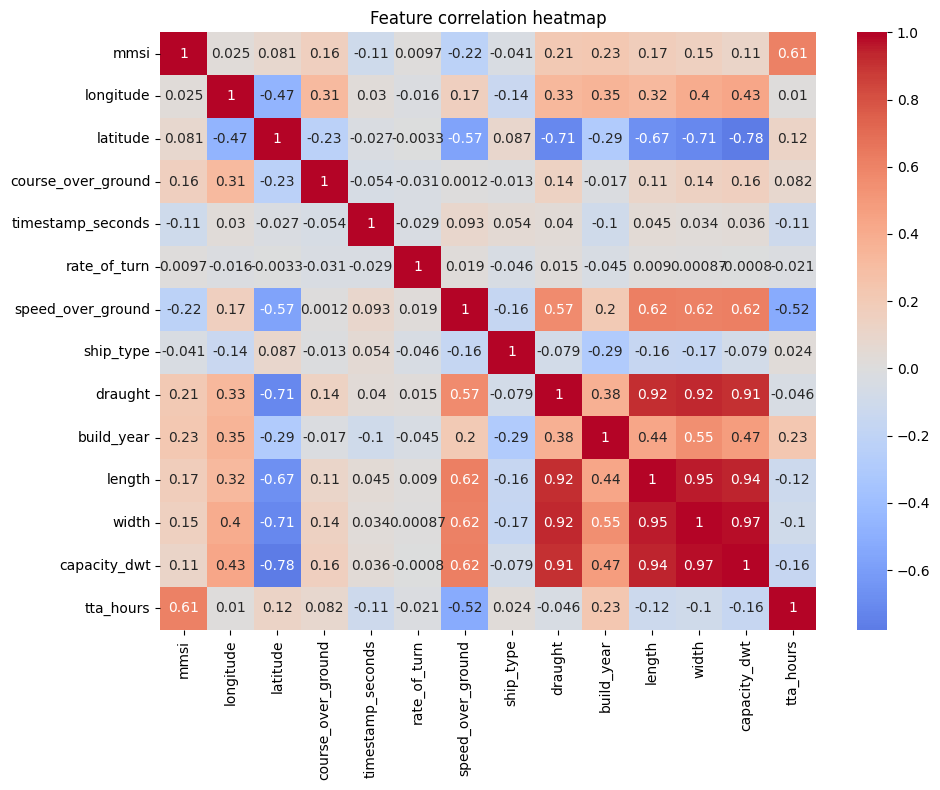

In [79]:
# seaborn correlation heatmap
import seaborn as sns

# 1) Select only numeric columns from your df (e.g. X_train)
num_df = X_train.select_dtypes(include=["number"])

# 2) Compute correlation matrix
corr = num_df.corr()

# 3) Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=True, center=0)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object", "category", "bool"]).columns.tolist()

# 1) Scale NUMERICS only, passthrough CATEGORICALS
preprocess_scale = ColumnTransformer(
    transformers=[
        ("cat", "passthrough", cat_cols),           # don't touch categoricals yet
        ("num", Normalizer(), num_cols),        # scale numerics only
    ]
)

# 2) Now one-hot + combine + PCA + RF
scale_pca_pipe_rforest = Pipeline(steps=[
    ("preprocess_scale", preprocess_scale),
    ("encode_cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),  # dense output
    ("pca", PCA(n_components=0.9)),
    ("rf", RandomForestRegressor(n_estimators=200, n_jobs=28, random_state=42))
])


In [81]:
scale_pca_pipe_rforest.fit(X_train, y_train)

,steps,"[('preprocess_scale', ...), ('encode_cat', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1) Predictions on validation set
y_pred = scale_pca_pipe_rforest.predict(X_val)

# 2) Core regression metrics
mae = mean_absolute_error(y_val, y_pred)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_val, y_pred)

print(f"MAE (hours):  {mae:.2f}")
print(f"RMSE (hours): {rmse:.2f}")
print(f"R²:           {r2:.5f}")

# 3) Optional: quick sanity check of errors
errors = y_pred - y_val
print(errors.describe())

MAE (hours):  1670.33
RMSE (hours): 3270.52
R²:           -50.88989
count    148396.000000
mean       1541.803233
std        2884.301711
min       -4333.651729
25%         -44.491405
50%          10.886099
75%        2561.803165
max       10998.645733
Name: tta_hours, dtype: float64


In [103]:
cargo_ais_meta_merged["speed_over_ground"].max()

np.float64(102.30000305175781)

In [104]:
cargo_ais_meta_merged["speed_over_ground"].describe()

count    742335.000000
mean         10.384700
std           6.988284
min           0.000000
25%           1.700000
50%          12.100000
75%          16.100000
max         102.300003
Name: speed_over_ground, dtype: float64

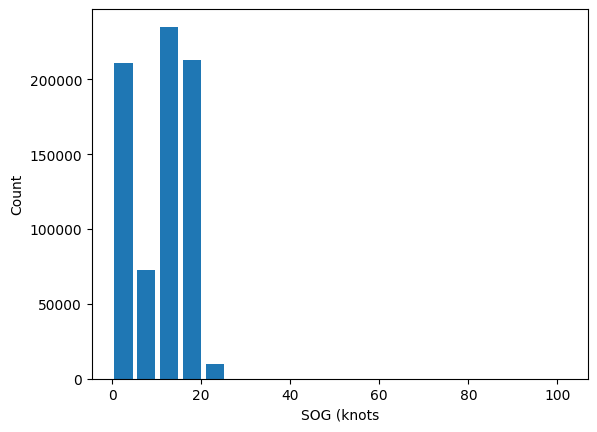

In [110]:
plt.hist(cargo_ais_meta_merged["speed_over_ground"], bins=20, rwidth=0.8)
plt.xlabel("SOG (knots")
plt.ylabel("Count")
plt.show()

In [84]:
X_train.sample(10) # gets 10 random samples for examination

,voyage_status,mmsi,navigation_status,position_accuracy,longitude,latitude,course_over_ground,timestamp_seconds,raim,rate_of_turn,...,position_device,draught,build_year,length,width,capacity_dwt,vessel_type_details,month,departure_locode,tta_hours
94159,UNDER_WAY,636018086,UNDER_WAY_USING_ENGINES,True,14.011427,36.282505,300.100006,0,True,0.0,...,GPS,9.9,2010,179.0,29.0,33261,Bulk Carrier,2024-01,MTDMP,67.950000
1136,UNDER_WAY,620331000,UNDER_WAY_USING_ENGINES,True,1.987642,39.168248,284.000000,41,False,720.0,...,GPS,9.7,1995,148.0,22.0,18233,Bulk Carrier,2024-01,TRZEY,11.705278
86496,UNDER_WAY,235077605,UNDER_WAY_USING_ENGINES,False,-46.343133,18.467850,64.000000,46,False,0.0,...,GPS,11.6,2005,186.0,32.0,48356,Tanker,2024-01,TTPTS,224.920556
79762,STOPPED,605086020,AT_ANCHOR,False,-0.275505,39.393687,348.399994,3,False,0.0,...,GPS,6.8,2017,170.0,28.0,23503,Container Ship,2024-01,DZAZW,8751.965556
39332,UNDER_WAY,210567000,UNDER_WAY_USING_ENGINES,True,0.024283,36.073600,3.000000,50,False,3.0,...,GPS,5.5,2009,155.0,24.0,3520,Roll-on Roll-off,2023-12,DZMOS,-31.848056
100687,STOPPED,563024600,UNDER_WAY_USING_ENGINES,True,-0.012615,39.453672,100.400002,16,False,0.0,...,GPS,9.0,2017,189.0,31.0,30205,Container Ship,2024-01,GRKTS,8771.809167
19287,STOPPED,247319800,AT_ANCHOR,False,-0.928315,49.533023,187.199997,25,False,0.0,...,GPS,7.4,2012,200.0,26.0,10786,Roll-on Roll-off,2024-01,FRLQT,23.509722
39381,STOPPED,255806363,AT_ANCHOR,False,2.187883,41.306602,94.000000,43,False,-1.0,...,GPS,6.6,2008,140.0,23.0,12558,Container Ship,2024-01,ESBCN,27.334444
94874,UNDER_WAY,636018086,UNDER_WAY_USING_ENGINES,True,14.069802,36.255640,298.899994,49,True,0.0,...,GPS,9.9,2010,179.0,29.0,33261,Bulk Carrier,2024-01,MTDMP,68.236389
100810,STOPPED,636020648,AT_ANCHOR,False,-0.249265,39.400843,204.800003,34,False,1.0,...,GPS,11.6,2009,261.0,32.0,50300,Container Ship,2024-01,ESBCN,8764.990556


#### Final valid AIS data samples (cargo_arrivals) in pct

In [ ]:
ratio = len(cargo_ais_meta_merged)/len(arrivals_ais_data) * 100
print(f"Valid AIS data samples (cargo_arrivals): {ratio:.2f}%")

RAIM and position_accuracy both indicate position accuracy

## Check out whether to merge AIS data and AIS META data

In [ ]:
print(f"Shortest voyage duration: {int(cargo_ais_meta_merged["duration"].min())}s")

In [ ]:
print(f"Longest voyage duration: {(cargo_ais_meta_merged["duration"].max() / (3600 * 24)).round(2)} days")

### Check long/lat or dist to port, SOG, draught/draught_max, navigation_status/ship_type

In [ ]:
cargo_ais_meta_merged["speed_over_ground"].describe().round(2)

In [ ]:
eta = arrivals_ais_data["eta"]
pct_valid_eta = eta.notna().mean() * 100
print(f"{pct_valid_eta:.2f}% of ETAs are valid")

## Exploratory data analysis

### Heat correlation map to determine variables correlating highly with ETA

## Data splitting

## Model development

## Evaluation